### Library Imports and JAX Backend Selection

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries and set JAX backend
import os
os.environ['JAX_PLATFORMS']="cuda" # select cpu instead if no gpu is available
# os.environ['JAX_PLATFORMS']="cpu"

from flax import nnx
import jax
import jax.numpy as jnp
import optax
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
# Set training and model restoration flags
overwrite_model = False
restore_model = True  # Use pretrained model if available
train_model = False  # Set to True to train from scratch

In [4]:
# Specify the checkpoint directory for saving/restoring models
import orbax.checkpoint as ocp
checkpoint_dir = f"{os.getcwd()}/checkpoints/diffusion_2d_example"

import os
os.makedirs(checkpoint_dir, exist_ok=True)

if overwrite_model:
    checkpoint_dir = ocp.test_utils.erase_and_create_empty(checkpoint_dir)

## 2. Data Generation

We generate a synthetic 2D dataset using JAX. This section defines the data generation functions and visualizes the data distribution.

In [5]:
# Define a function to generate 2D box data using JAX
import jax
import jax.numpy as jnp
from jax import random
from functools import partial
import grain

@partial(jax.jit, static_argnums=[1])  # type: ignore
def make_boxes_jax(key, batch_size: int = 200):
    """
    Generates a batch of 2D data points similar to the original PyTorch function
    using JAX.

    Args:
        key: A JAX PRNG key for random number generation.
        batch_size: The number of data points to generate.

    Returns:
        A JAX array of shape (batch_size, 2) with generated data,
        with dtype float32.
    """
    # Split the key for different random operations
    keys = jax.random.split(key, 3)
    x1 = jax.random.uniform(keys[0],batch_size) * 4 - 2
    x2_ = jax.random.uniform(keys[1],batch_size) - jax.random.randint(keys[2], batch_size, 0,2) * 2
    x2 = x2_ + (jnp.floor(x1) % 2)

    data = 1.0 * jnp.concatenate([x1[:, None], x2[:, None]], axis=1) / 0.45

    return data

In [6]:
# # Infinite data generator for training batches
# @partial(jax.jit, static_argnums=[1])  # type: ignore
# def inf_train_gen(key, batch_size: int = 200):
#     x = make_boxes_jax(key, batch_size)

#     return x

batch_size = 256

data = make_boxes_jax(jax.random.PRNGKey(0), 500_000)

# normalize the data
mean_ = jnp.mean(data)
std_ = jnp.std(data)

data = (data - mean_ ) / std_

train_dataset_grain = (
    grain.MapDataset.source(np.array(data)[...,None])
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
)


train_dataset_batched = train_dataset_grain.batch(batch_size)

train_iter = iter(train_dataset_batched)

data_val = make_boxes_jax(jax.random.PRNGKey(1), 1000)

data_val = (data_val - mean_ ) / std_

val_dataset_batched = (
    grain.MapDataset.source(np.array(data_val)[...,None])
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
    .batch(512)
)

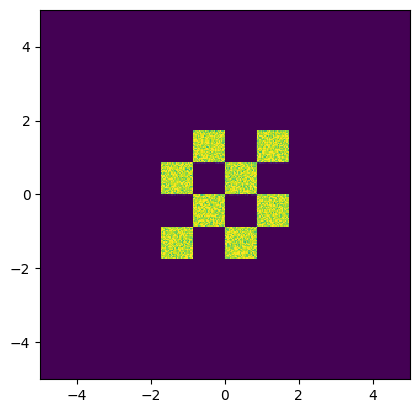

In [7]:
# Visualize the generated data distribution
samples = np.array(data)

H=plt.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)))
cmin = 0.0
cmax = jnp.quantile(jnp.array(H[0]), 0.99).item()
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

_ = plt.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)), norm=norm, cmap="viridis")

# set equal ratio of axes
plt.gca().set_aspect('equal', adjustable='box')


plt.show()

## 3. Model and Loss Definition

We define the velocity field model (an MLP), the loss function, and the optimizer for training the score-matching model.

In [8]:
# Import diffusion components and utilities
from gensbi.recipes import UnconditionalSMPipeline

/home/aure/miniforge3/envs/gensbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Define the MLP velocity field model
class MLP(nnx.Module):
    def __init__(self, input_dim: int = 2, hidden_dim: int = 128, *, rngs: nnx.Rngs):

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        din = input_dim + 1

        self.linear1 = nnx.Linear(din, self.hidden_dim, rngs=rngs)
        self.linear2 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear3 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear4 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear5 = nnx.Linear(self.hidden_dim, self.input_dim, rngs=rngs)

    def __call__(self, t: jax.Array, obs: jax.Array,  **kwargs):
        assert obs.ndim == 3, f"Input obs must have shape (batch_size, input_dim, 1), got {obs.shape}"

        # we need to massage the data a bit to make it compatible with the pipeline format
        t = jnp.atleast_1d(t)
        x = jnp.squeeze(obs, axis=-1)


        if t.ndim<2:
            t = t[..., None]

        if t.ndim==3:
            t = t[...,0]

        t = jnp.broadcast_to(t, (x.shape[0], t.shape[-1]))

        # now everything whould have the right dimension, we can proceed

        h = jnp.concatenate([x, t], axis=-1)

        x = self.linear1(h)
        x = jax.nn.gelu(x)

        x = self.linear2(x)
        x = jax.nn.gelu(x)

        x = self.linear3(x)
        x = jax.nn.gelu(x)

        x = self.linear4(x)
        x = jax.nn.gelu(x)

        x = self.linear5(x)

        return x[...,None]

# VP model

In [10]:
# Initialize the velocity field model
hidden_dim = 512

# velocity field model init
model = MLP(input_dim=2, hidden_dim=hidden_dim, rngs=nnx.Rngs(0))

training_config = UnconditionalSMPipeline.get_default_training_config()
training_config["checkpoint_dir"] = checkpoint_dir
training_config["nsteps"] = 10_000


pipeline = UnconditionalSMPipeline(model,
    train_dataset_batched,
    val_dataset_batched,
    2,
    training_config=training_config,
    sde_type="VP")

In [11]:
pipeline.train(nnx.Rngs(0), save_model=False)

100%|██████████| 10000/10000 [01:57<00:00, 85.36it/s, counter=0, loss=23.5971, ratio=1.0027, val_loss=19.5060]


([Array(24.366402, dtype=float32),
  Array(25.119986, dtype=float32),
  Array(25.757505, dtype=float32),
  Array(24.522127, dtype=float32),
  Array(24.573128, dtype=float32),
  Array(25.074026, dtype=float32),
  Array(24.44034, dtype=float32),
  Array(24.759064, dtype=float32),
  Array(24.722427, dtype=float32),
  Array(23.533096, dtype=float32),
  Array(24.448498, dtype=float32),
  Array(24.97272, dtype=float32),
  Array(25.085407, dtype=float32),
  Array(24.31457, dtype=float32),
  Array(24.344767, dtype=float32),
  Array(23.215794, dtype=float32),
  Array(22.901459, dtype=float32),
  Array(24.225275, dtype=float32),
  Array(25.115967, dtype=float32),
  Array(24.377447, dtype=float32),
  Array(24.524391, dtype=float32),
  Array(23.897085, dtype=float32),
  Array(24.00581, dtype=float32),
  Array(24.64228, dtype=float32),
  Array(24.925941, dtype=float32),
  Array(24.56085, dtype=float32),
  Array(24.676382, dtype=float32),
  Array(24.243181, dtype=float32),
  Array(25.286926, dtype=f

In [12]:
key = jax.random.PRNGKey(42)
# time steps: 20,
sol_ = pipeline.sample(key, nsamples=100_000, nsteps=100, return_intermediates=True)
jax.block_until_ready(sol_)

Array([[[[ 0.07592554],
         [-0.48634264]],

        [[ 1.2903206 ],
         [ 0.5196119 ]],

        [[ 0.30040437],
         [ 0.31034866]],

        ...,

        [[-0.2266365 ],
         [ 1.0944828 ]],

        [[ 0.5758258 ],
         [-0.6356034 ]],

        [[-0.15315211],
         [-0.5441804 ]]],


       [[[ 0.16125676],
         [-0.3655014 ]],

        [[ 1.3524352 ],
         [ 0.78795993]],

        [[ 0.48073155],
         [ 0.11369573]],

        ...,

        [[-0.10282106],
         [ 1.1624199 ]],

        [[ 0.49573267],
         [-0.75412285]],

        [[-0.05000135],
         [-0.8889055 ]]],


       [[[-0.03946991],
         [-0.4175616 ]],

        [[ 1.4471195 ],
         [ 1.0784136 ]],

        [[ 0.3965415 ],
         [-0.2633682 ]],

        ...,

        [[ 0.14670014],
         [ 1.0038769 ]],

        [[ 0.45810172],
         [-0.4494186 ]],

        [[-0.01355883],
         [-0.96242803]]],


       ...,


       [[[ 0.43222597],
         [ 0.6

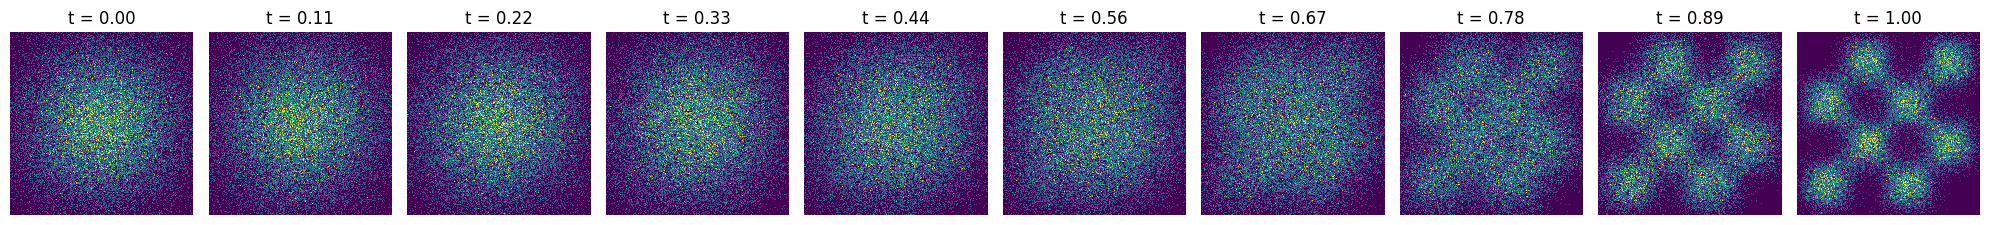

In [13]:
# Visualize the sampled trajectories at different time steps
sol = np.array(sol_[::10])*std_ + mean_  # convert to numpy array, take only one step every 2
T = np.linspace(0,1,10)  # convert to numpy array

fig, axs = plt.subplots(1, 10, figsize=(20,20))

for i in range(10):
    H = axs[i].hist2d(sol[i,:,0,0], sol[i,:,1,0], 300, range=((-5,5), (-5,5)))

    cmin = 0.0
    cmax = jnp.quantile(jnp.array(H[0]), 0.99).item()

    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

    _ = axs[i].hist2d(sol[i,:,0,0], sol[i,:,1,0], 300, range=((-5,5), (-5,5)), norm=norm, cmap="viridis")

    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t = %.2f' % (T[i]))

plt.tight_layout()
plt.show()

In [14]:
# Import plotting utility for marginals
from gensbi.utils.plotting import plot_marginals

In [15]:
sol_ = pipeline.sample(key, nsamples=500_000, nsteps=100, return_intermediates=False)
jax.block_until_ready(sol_)

Array([[[ 0.44478944],
        [ 0.61418456]],

       [[ 1.7420518 ],
        [-0.16648021]],

       [[-0.35553023],
        [-0.5723491 ]],

       ...,

       [[ 0.506967  ],
        [ 0.50091857]],

       [[ 0.3078044 ],
        [ 0.42015746]],

       [[ 1.4051608 ],
        [ 1.3099438 ]]], dtype=float32)

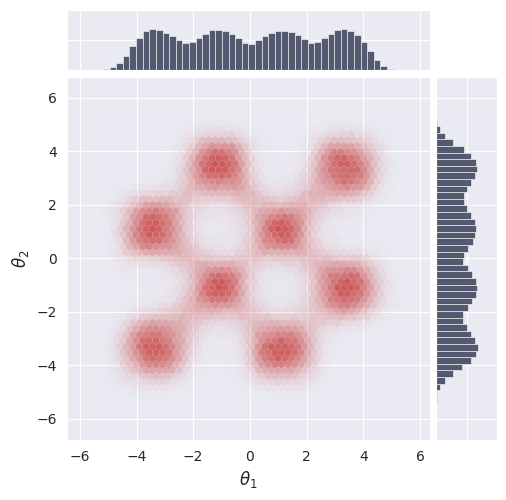

In [16]:
# Plot the marginal distribution of the final samples
plot_marginals(sol_[...,0]*std_ + mean_, plot_levels=False, gridsize=50, backend="seaborn")
plt.show()

# VE model

In [17]:
# Initialize the velocity field model
hidden_dim = 512

# velocity field model init
model = MLP(input_dim=2, hidden_dim=hidden_dim, rngs=nnx.Rngs(0))

training_config = UnconditionalSMPipeline.get_default_training_config()
training_config["checkpoint_dir"] = checkpoint_dir
training_config["nsteps"] = 10_000


pipeline = UnconditionalSMPipeline(model,
    train_dataset_batched,
    val_dataset_batched,
    2,
    training_config=training_config,
    sde_type="VE")

In [18]:
pipeline.train(nnx.Rngs(0), save_model=False)

100%|██████████| 10000/10000 [01:48<00:00, 91.96it/s, counter=0, loss=27.4405, ratio=1.0000, val_loss=24.7858] 


([Array(741.04675, dtype=float32),
  Array(295.19833, dtype=float32),
  Array(136.83832, dtype=float32),
  Array(81.55436, dtype=float32),
  Array(61.420284, dtype=float32),
  Array(56.167095, dtype=float32),
  Array(53.394608, dtype=float32),
  Array(52.343094, dtype=float32),
  Array(48.127335, dtype=float32),
  Array(46.59776, dtype=float32),
  Array(44.501102, dtype=float32),
  Array(43.242943, dtype=float32),
  Array(44.470417, dtype=float32),
  Array(41.387074, dtype=float32),
  Array(40.28819, dtype=float32),
  Array(39.797207, dtype=float32),
  Array(38.39193, dtype=float32),
  Array(38.582516, dtype=float32),
  Array(37.633648, dtype=float32),
  Array(37.434647, dtype=float32),
  Array(36.770412, dtype=float32),
  Array(36.13245, dtype=float32),
  Array(34.95661, dtype=float32),
  Array(34.52847, dtype=float32),
  Array(33.52734, dtype=float32),
  Array(32.773605, dtype=float32),
  Array(32.619045, dtype=float32),
  Array(32.33597, dtype=float32),
  Array(31.51733, dtype=float

In [19]:
key = jax.random.PRNGKey(42)
# time steps: 20,
sol_ = pipeline.sample(key, nsamples=100_000, nsteps=100, return_intermediates=True)
jax.block_until_ready(sol_)

Array([[[[  1.138883  ],
         [ -7.29514   ]],

        [[ 19.354809  ],
         [  7.7941785 ]],

        [[  4.5060654 ],
         [  4.65523   ]],

        ...,

        [[ -3.3995476 ],
         [ 16.417242  ]],

        [[  8.637387  ],
         [ -9.534052  ]],

        [[ -2.2972817 ],
         [ -8.162706  ]]],


       [[[  4.2861323 ],
         [ -1.57655   ]],

        [[ 17.863605  ],
         [ 16.620583  ]],

        [[ 10.67897   ],
         [ -3.401775  ]],

        ...,

        [[  2.180231  ],
         [ 15.400148  ]],

        [[  4.764228  ],
         [-12.819372  ]],

        [[  1.7203522 ],
         [-20.441364  ]]],


       [[[ -3.3404055 ],
         [ -3.5175512 ]],

        [[ 18.225245  ],
         [ 23.825108  ]],

        [[  6.740486  ],
         [-16.159725  ]],

        ...,

        [[ 10.25444   ],
         [  6.923709  ]],

        [[  2.870024  ],
         [ -0.03061867]],

        [[  2.8475776 ],
         [-18.42022   ]]],


       ...,


  

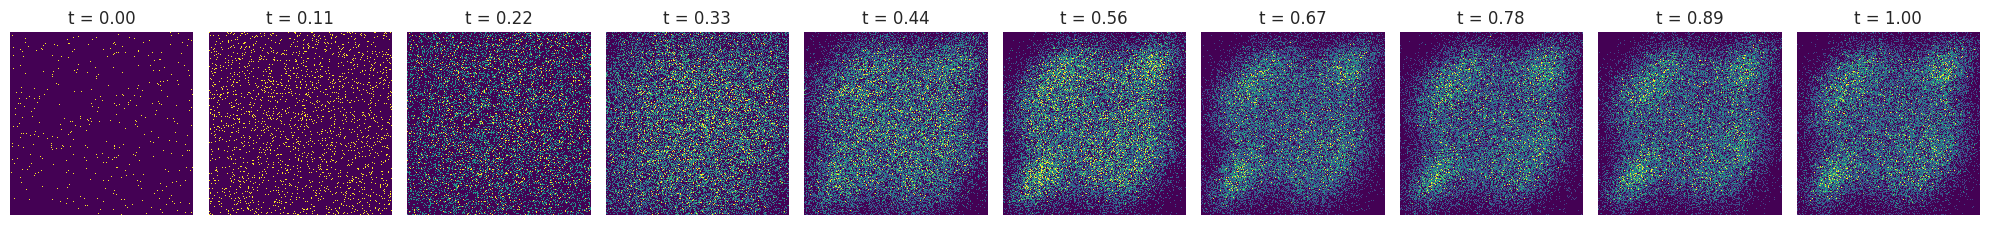

In [20]:
# Visualize the sampled trajectories at different time steps
sol = np.array(sol_[::10])*std_ + mean_  # convert to numpy array, take only one step every 2
T = np.linspace(0,1,10)  # convert to numpy array

fig, axs = plt.subplots(1, 10, figsize=(20,20))

for i in range(10):
    H = axs[i].hist2d(sol[i,:,0,0], sol[i,:,1,0], 300, range=((-5,5), (-5,5)))

    cmin = 0.0
    cmax = jnp.quantile(jnp.array(H[0]), 0.99).item()

    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

    _ = axs[i].hist2d(sol[i,:,0,0], sol[i,:,1,0], 300, range=((-5,5), (-5,5)), norm=norm, cmap="viridis")

    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t = %.2f' % (T[i]))

plt.tight_layout()
plt.show()

In [21]:
# Import plotting utility for marginals
from gensbi.utils.plotting import plot_marginals

In [22]:
sol_ = pipeline.sample(key, nsamples=500_000, nsteps=100, return_intermediates=False)
jax.block_until_ready(sol_)

Array([[[ 1.5046915 ],
        [ 0.8394092 ]],

       [[13.667935  ],
        [-0.642648  ]],

       [[ 0.42950988],
        [-0.27285475]],

       ...,

       [[-0.22648267],
        [ 0.67560184]],

       [[ 1.0235839 ],
        [ 0.12228358]],

       [[ 6.410515  ],
        [11.161635  ]]], dtype=float32)

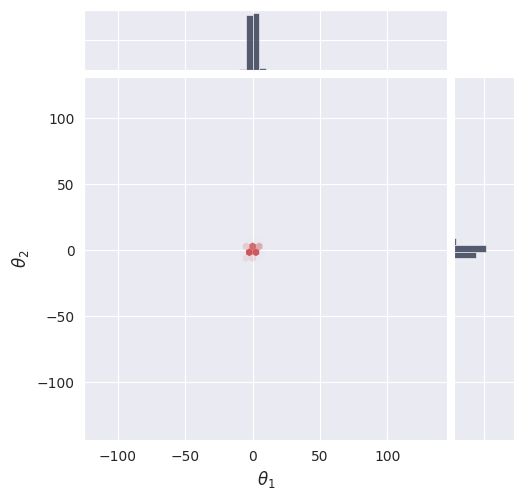

In [23]:
# Plot the marginal distribution of the final samples
plot_marginals(sol_[...,0]*std_ + mean_, plot_levels=False, gridsize=50, backend="seaborn")
plt.show()